In [1]:
!pip install google-generativeai pillow langchain-chroma

In [2]:
import ollama
def ask_llm(prompt):
    response = ollama.chat(
        model = "llama3:8b",
        messages = [{
            "role" : "user",
            "content" : prompt
        }],
        stream = true
    )
    for res in response:
        print(res['messages']['content'],end="",flush = True)

In [3]:
import requests

def generate_response(prompt):

    response = requests.post(
        "https://text.golvereshma.workers.dev/",
        headers={
            "Authorization": "Bearer 9876543210",
            "Content-Type": "application/json"
        },
        json={
            "prompt": prompt
        }
    )
    data = response.json()
    print(data)
    print(data['response'])
    return data['response']


In [4]:
generate_response("hey hi")

{'response': "It's nice to meet you. Is there something I can help you with or would you like to chat?"}
It's nice to meet you. Is there something I can help you with or would you like to chat?


"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [5]:
from docling.document_converter import(
    DocumentConverter,
    PdfFormatOption
)
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
pipeline_options=PdfPipelineOptions()
pipeline_options.generate_picture_images=True
pipeline_options.generate_page_images=True
converter=DocumentConverter(
    format_options={
        InputFormat.PDF:PdfFormatOption(
            pipeline_options=pipeline_options

        )
    }
)
result=converter.convert("C:/Users/golve/Downloads/AI_Report.pdf")
doc=result.document


The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[INFO] 2026-06-17 11:45:37,997 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-17 11:45:38,013 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\golve\AppData\Local\Programs\Python\Python313\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-17 11:45:38,015 [RapidOCR] main.py:65: Using C:\Users\golve\AppData\Local\Programs\Python\Python313\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-17 11:45:38,220 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-17 11:45:38,222 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\golve\AppData\Local\Programs\Python\Python313\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onn

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.


[PictureItem(self_ref='#/pictures/0', parent=RefItem(cref='#/body'), children=[RefItem(cref='#/texts/2')], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.PICTURE: 'picture'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=146.26585388183594, t=586.6399536132812, r=447.9601135253906, b=434.7503356933594, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))], source=[], comments=[], captions=[], references=[], footnotes=[], image=ImageRef(mimetype='image/png', dpi=72, size=Size(width=302.0, height=152.0), uri=AnyUrl('')), annotations=[])]
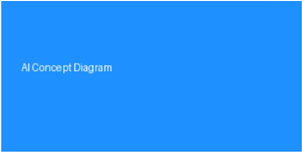

In [6]:
doc.pictures

In [7]:
print(len(doc.pictures))

1


In [8]:
from docling.chunking import HybridChunker
chunker=HybridChunker()
chunks=list(chunker.chunk(dl_doc=doc))

In [9]:
!pip install google-generativeai

In [10]:
len(chunks)

1

In [11]:
chunks[0]

DocChunk(text='Artificial Intelligence (AI) is a branch of computer science that focuses on creating machines capable of performing tasks that typically require human intelligence such as learning, reasoning, and decision making.\nType, 1 = Description. Narrow AI, 1 = Performs specific tasks like voice assistants. General AI, 1 = Human-like intelligence (theoretical). Super AI, 1 = Smarter than humans (future concept)', meta=DocMeta(schema_name='docling_core.transforms.chunker.DocMeta', version='1.0.0', doc_items=[DocItem(self_ref='#/texts/1', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.TEXT: 'text'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=78.0, t=715.0697705078124, r=506.52000000000004, b=681.8197705078124, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 214))], source=[], comments=[]), DocItem(self_ref='#/tables/0', parent=RefItem(cref='#/body'), children=[], content_layer=<Conten

In [12]:
import google.generativeai as genai
genai.configure(api_key="AQ.Ab8RN6JPoeGgIcf6x78bnk0Haf9AXvLa4pOsszruSVbF3n-Www")
model = genai.GenerativeModel("gemini-2.5-flash")

C:\Users\golve\AppData\Local\Temp\ipykernel_7688\3359837984.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [13]:
def summarize_chunk(chunk):
    TEXT_PROMPT = f"""
Summarize the following chunk.
Preserve important names, numbers and facts.
Return only the summary.

Chunk:
{chunk}
"""
    return generate_response(TEXT_PROMPT)

In [14]:
IMAGE_PROMPT = """
Generate a comprehensive semantic description of this image for use in a multimodal retrieval system.

Describe all visible content including:
- Titles and headings
- Objects and entities
- Text and numbers
- Tables and charts
- Axes, legends and units
- Diagrams and flowcharts
- Relationships between components
- Colors and layout when important
- Statistics and measurements
- Technical terminology
- Key conclusions and insights

Preserve names, dates, values, and identifiers exactly.

Produce a detailed, self-contained description so that a user can answer questions about the image without directly seeing it.

Return only the description.
"""

In [15]:
def summarize_image(image):

    response = model.generate_content(
        [
            IMAGE_PROMPT,
            image
        ]
    )

    print(response.text)

    return response.text
    

In [16]:
documents = []
from langchain_core.documents import Document

In [17]:
from langchain_core.documents import Document

documents = []

for chunk in chunks:
    print("chunked")
    summary = summarize_chunk(str(chunk.text))

    documents.append(
        Document(
            page_content=summary,
            metadata={
                "type": "text"
            }
        )
    )

chunked
{'response': 'Artificial Intelligence (AI) is a branch of computer science that creates machines to perform human-like tasks. There are 3 types of AI: Narrow AI, which performs specific tasks like voice assistants, General AI, which aims for human-like intelligence, and Super AI, which is a future concept that would be smarter than humans.'}
Artificial Intelligence (AI) is a branch of computer science that creates machines to perform human-like tasks. There are 3 types of AI: Narrow AI, which performs specific tasks like voice assistants, General AI, which aims for human-like intelligence, and Super AI, which is a future concept that would be smarter than humans.


In [18]:
# Add images
for picture in doc.pictures:

    image = picture.get_image(doc)

    if image is None:
        continue

    summary = summarize_image(image)

    documents.append(
        Document(
            page_content=summary,
            metadata={
                "type": "image"
            }
        )
    )

The image displays a simple, minimalist graphic with a solid blue background. In the top-left quadrant, white text reads "AI Concept Diagram". This text serves as a title or heading, indicating the subject matter of a concept diagram related to Artificial Intelligence. There are no other visible objects, entities, numbers, tables, charts, axes, legends, units, diagrams, flowcharts, or statistical information. The overall layout is clean, with the white text contrasting clearly against the bright blue background. The image appears to be an introductory slide or a placeholder for a more complex diagram that will follow, setting the context for an AI-related conceptual visualization.


In [19]:
len(documents)

2

In [20]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="mixedbread-ai/mxbai-embed-large-v1",
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [47]:
from langchain_chroma import Chroma

vectorstore = Chroma(
    collection_name="multimodal_rag",
    persist_directory="./chroma_mragdb",
    embedding_function=embeddings
)

In [48]:
vectorstore._collection.count()

0

In [49]:
vectorstore.add_documents(documents)

['85edb426-8952-4d1a-826c-1cd1c316a600',
 'da848eaa-3315-4e42-bdb5-f6b73a1dab2f']

In [50]:
vectorstore._collection.count()

2

In [51]:
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k":20,
        "fetch_k":50
    }
)

In [52]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "BAAI/bge-reranker-large",
)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [53]:
def retrieve(query, top_k=5):

    docs = retriever.invoke(query)

    pairs = [
        [query, doc.page_content]
        for doc in docs
    ]

    scores = reranker.predict(pairs)

    ranked_docs = sorted(
        zip(scores, docs),
        key=lambda x: x[0],
        reverse=True
    )

    return [
        doc
        for score, doc in ranked_docs[:top_k]
    ]

In [54]:
def build_context(query):

    retrieved_docs = retrieve(query)

    context = "\n\n".join(
        doc.page_content
        for doc in retrieved_docs
    )

    return context

In [58]:
import requests

def generate_response(prompt):

    response = requests.post(
        "https://text.golvereshma.workers.dev/",
        headers={
            "Authorization": "Bearer 9876543210",
            "Content-Type": "application/json"
        },
        json={
            "prompt": prompt
        }
    )

   

In [59]:
def ask(query):

    context = build_context(query)
    print(f"The context retrived is:{context}")

    prompt = f"""
You are a helpful assistant.

Answer the question using ONLY the context below.

If the answer is not present, say:
'I could not find the answer in the provided context.'

Context:
{context}

Question:
{query}

Answer:
"""

    return generate_response(prompt)

In [60]:
answer = ask(
    "What is the problem statement gimme in a single line"
)

print(answer)

The context retrived is:The image displays a simple, minimalist graphic with a solid blue background. In the top-left quadrant, white text reads "AI Concept Diagram". This text serves as a title or heading, indicating the subject matter of a concept diagram related to Artificial Intelligence. There are no other visible objects, entities, numbers, tables, charts, axes, legends, units, diagrams, flowcharts, or statistical information. The overall layout is clean, with the white text contrasting clearly against the bright blue background. The image appears to be an introductory slide or a placeholder for a more complex diagram that will follow, setting the context for an AI-related conceptual visualization.

Artificial Intelligence (AI) is a branch of computer science that creates machines to perform human-like tasks. There are 3 types of AI: Narrow AI, which performs specific tasks like voice assistants, General AI, which aims for human-like intelligence, and Super AI, which is a future 

In [37]:
from transformers import AutoTokenizer
from docling.chunking import HybridChunker

tokenizer = AutoTokenizer.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2"
)

In [38]:
chunker = HybridChunker(
    tokenizer=tokenizer,
    max_tokens=1024
)

chunks = list(chunker.chunk(dl_doc=doc))

In [39]:
len(chunks)

1

In [40]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


splitter = RecursiveCharacterTextSplitter(
    chunk_size=3000,
    chunk_overlap=600
)

docs = []

for chunk in chunks:
    docs.extend(
        splitter.create_documents(
            [chunk.text]
        )
    )

In [41]:
len(docs)

1

In [42]:
docs[0]

Document(metadata={}, page_content='Artificial Intelligence (AI) is a branch of computer science that focuses on creating machines capable of performing tasks that typically require human intelligence such as learning, reasoning, and decision making.\nType, 1 = Description. Narrow AI, 1 = Performs specific tasks like voice assistants. General AI, 1 = Human-like intelligence (theoretical). Super AI, 1 = Smarter than humans (future concept)')